**INTRODUCTION TO BIGDATA AND DATA SCIENCE**


**ASSIGNMENT -7**


**NAME:Karunya Mekala**

**Student ID: 11818036**

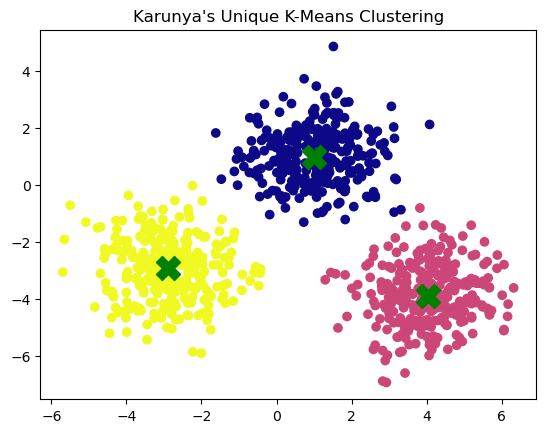

In [10]:
import numpy as pn
import matplotlib.pyplot as plt

def karunya_squared_distance(k, v):
    return pn.sum((k - v) ** 2)

class KarunyaClusterer:
    def __init__(self, clusters=5, max_iter=120, tolerance=1e-4):
        self.k_clusters = clusters
        self.k_max_iter = max_iter
        self.k_tolerance = tolerance
        self.final_centroids = None
        self.assignments = None
    
    def fit_data(self, karunya_data):
        
        init_indices = pn.random.choice(len(karunya_data), self.k_clusters, replace=False)
        current_centroids = karunya_data[init_indices]

        for iteration in range(self.k_max_iter):
            clusters = self.assign_clusters(karunya_data, current_centroids)
        
            new_centroids = pn.array([karunya_data[clusters == k].mean(axis=0) for k in range(self.k_clusters)])
            
            if pn.all(pn.abs(new_centroids - current_centroids) < self.k_tolerance):
                break
            
            current_centroids = new_centroids

        self.final_centroids = current_centroids
        self.assignments = clusters

    def assign_clusters(self, data_points, centroids):
        distances = pn.zeros((data_points.shape[0], self.k_clusters))
        for idx, centroid in enumerate(centroids):
            distances[:, idx] = pn.array([karunya_squared_distance(point, centroid) for point in data_points])
        return pn.argmin(distances, axis=1)

    def predict_clusters(self, new_data):
        return self.assign_clusters(new_data, self.final_centroids)

pn.random.seed(42)
karunya_group_1 = pn.random.randn(300, 2) + pn.array([1, 1])
karunya_group_2 = pn.random.randn(300, 2) + pn.array([-3, -3])
karunya_group_3 = pn.random.randn(300, 2) + pn.array([4, -4])

karunya_big_data = pn.vstack((karunya_group_1, karunya_group_2, karunya_group_3))

karunya_model = KarunyaClusterer(clusters=3)
karunya_model.fit_data(karunya_big_data)

plt.scatter(karunya_big_data[:, 0], karunya_big_data[:, 1], c=karunya_model.assignments, cmap='plasma')
plt.scatter(karunya_model.final_centroids[:, 0], karunya_model.final_centroids[:, 1], s=300, c='green', marker='X')
plt.title("Karunya's Unique K-Means Clustering")
plt.show()


1. **Distance Calculation**:
   - The `karunya_squared_distance` function calculates the squared distance between two points, helping to measure how far a data point is from a centroid. By skipping the square root, it simplifies the calculation, making it more efficient without affecting the accuracy of distance comparisons for clustering.

2. **KarunyaClusterer Class**:
   - **Constructor (`__init__`)**: 
     - In the clustering process, we begin by defining a few essential parameters. First, we specify the number of clusters we want to create, referred to as "clusters." Next, we set a limit on the number of iterations the algorithm will run, known as "max iterations." This ensures that the algorithm doesn't run indefinitely while searching for the best clusters. Additionally, we establish a "tolerance" value, a small threshold that helps us determine when the centroids—the central points of the clusters—are no longer changing significantly. This signals that the algorithm has converged on a solution. Once the model has been fitted, it retains the final positions of the centroids along with the assignments of data points to their respective clusters, effectively organizing the data into meaningful groups.
   - **`fit_data()`**:
     - Randomly selects initial centroids from the dataset.
     - Assigns each data point to the nearest centroid based on distance.
     - The algorithm updates the centroids by calculating the mean of all the points assigned to each cluster. This process is repeated iteratively, continuing until one of two conditions is met: either the maximum number of iterations has been reached, or the changes in the centroids fall below a specified threshold, known as the "tolerance." This ensures that the centroids stabilize and reflect the true center of their respective clusters before concluding the clustering process.
       
   - **`assign_clusters()`**:
     - This method calculates the distance between each data point and all centroids, then assigns each point to the nearest centroid using `pn.argmin()` to find the minimum distance.

   - **`predict_clusters()`**:
     - After the model is fitted, this method predicts the cluster membership of new data points by assigning them to the nearest learned centroids.

3. **Data Generation**:
   - Three synthetic clusters are created using random numbers, each centered at a different location in a 2D space.
   - These datasets simulate real clusters and are combined into a single dataset for testing the K-Means clustering algorithm.

4. **Model Fitting**:
   - The `fit_data()` method is applied to the combined dataset (`karunya_big_data`). This trains the K-Means model by assigning data points to the closest clusters, updating centroids, and iterating until the clusters stabilize (i.e., the centroids stop moving significantly).

5. **Visualization**:
   - The results of the clustering are visualized using `matplotlib`, where data points are colored according to their assigned clusters.
   - The final centroids are marked with large green'X' symbols, showing their locations after the algorithm has converged. This provides a clear visual representation of how the data points have been grouped into clusters.